# Climatology of shear-relative eddy tilt and its evolution
**Questions:** Do AEs and CEs have a preferred along/against/across-shear orientation? Does it differ between planetary and topographic conditions? Given the current orientation, how does coherent tilt change over the next 1, 3 and 5 days?

This is a population analysis; no case studies or hand-selected eddies. Positive parallel = downshear; negative = upshear; positive transverse = left. The primary tilt is the existing measured lower-to-upper `TiltDis`/`TiltDir`, never recalculated from noisy daily centre positions.

**Scope:** whole-column tilt is compared with 0-200 m minus 200-500 m background flow. These depth supports are not identical. Results describe geometric organisation and conditional evolution, not an exact layer-displacement budget, evidence of baroclinic instability, or proof of phase locking. Cross-shear behaviour is tested with no imposed AE/CE sign.

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Launch from seacofs_eddy_tilt_analysis or this subfolder.')
THIS_ROOT = ANALYSIS_ROOT / 'shear_tilt_climatology'
for p in (ANALYSIS_ROOT, THIS_ROOT):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
import climatology_tools as ct
CACHE_ROOT = Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/shear_tilt_climatology')
INPUT_PATH = CACHE_ROOT / 'climatology_inputs.parquet'
METADATA_PATH = CACHE_ROOT / 'input_metadata.json'
pd.set_option('display.max_columns', 40)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
FAMILY = 'clim'
DEFINITION = 'upper_deep'
MIN_TILT_KM = 5.0
MIN_SHEAR_MS = 0.005
DOMINANCE_FACTOR = 2.0
PLANETARY_MIN_DEPTH_M = 3000.0
SMOOTHING = 'trailing'
SMOOTH_WINDOW = 7
SMOOTH_MIN_PERIODS = 5
LAGS = (1, 3, 5)
PRIMARY_LAG = 3
BOOTSTRAPS = 500
MIN_EDDIES = 20
MIN_ROWS = 50
SEED = 20260915
RUN_SENSITIVITIES = True
SAVE_OUTPUTS = True
if not INPUT_PATH.exists(): raise FileNotFoundError('Run 00_prepare_inputs.ipynb first.')
raw = pd.read_parquet(INPUT_PATH)
ct.validate_days(raw)
settings = dict(family=FAMILY, definition=DEFINITION, min_tilt=MIN_TILT_KM, min_shear=MIN_SHEAR_MS,
                dominance_factor=DOMINANCE_FACTOR, planetary_depth=PLANETARY_MIN_DEPTH_M,
                smoothing=SMOOTHING, window=SMOOTH_WINDOW, min_periods=SMOOTH_MIN_PERIODS,
                lags=LAGS, primary_lag=PRIMARY_LAG, bootstraps=BOOTSTRAPS,
                min_eddies=MIN_EDDIES, min_rows=MIN_ROWS, seed=SEED)
if PRIMARY_LAG not in LAGS: raise ValueError('PRIMARY_LAG must belong to LAGS.')
run_id = pd.Timestamp.now(tz='UTC').strftime('%Y%m%dT%H%M%S%fZ')
OUTPUT = CACHE_ROOT / 'results' / run_id
if SAVE_OUTPUTS:
    OUTPUT.mkdir(parents=True, exist_ok=True)
    provenance = dict(settings=settings, input_metadata=json.loads(METADATA_PATH.read_text()),
                      helper_sha256=hashlib.sha256((THIS_ROOT/'climatology_tools.py').read_bytes()).hexdigest())
    (OUTPUT/'settings.json').write_text(json.dumps(provenance, indent=2))
def show(fig, name):
    if SAVE_OUTPUTS: fig.savefig(OUTPUT/f'{name}.png', dpi=160, bbox_inches='tight')
    plt.show(); plt.close(fig)
def table(frame, name):
    display(frame)
    if SAVE_OUTPUTS: frame.to_csv(OUTPUT/f'{name}.csv', index=False)
def summarize(frame, metrics, groups=ct.GROUPS, weighting='day'):
    return ct.cluster_summary(frame, metrics, groups=groups, weighting=weighting,
        n_boot=BOOTSTRAPS, min_eddies=MIN_EDDIES, min_rows=MIN_ROWS, seed=SEED)
def prepare(frame, **overrides):
    options = dict(family=FAMILY, definition=DEFINITION, min_shear=MIN_SHEAR_MS, min_tilt=MIN_TILT_KM)
    options.update({k:v for k,v in overrides.items() if k in options})
    regimes = ct.classify_regimes(frame, factor=overrides.get('factor', DOMINANCE_FACTOR),
        window=SMOOTH_WINDOW, min_periods=SMOOTH_MIN_PERIODS,
        planetary_depth=PLANETARY_MIN_DEPTH_M, smoothing=overrides.get('smoothing', SMOOTHING))
    return ct.relative_geometry(regimes, **options)
data = prepare(raw)
eligible = data.loc[data.eligible].copy()
if eligible.empty: raise ValueError('No eligible observations; inspect inputs and prespecified thresholds.')

## 1. Sample support and environmental coverage
All eddy-days remain in `data`. Missing days, regime changes, weak/invalid shear and invalid/small tilt break temporal episodes. Pairs require every day between endpoints to be eligible in the same regime. One eddy may contribute to both regimes and multiple episodes.

Planetary means smoothed topographic/planetary magnitude ratio <= 1/2 and core-mean h >= 3000 m; topographic means ratio >= 2. Other valid conditions are mixed. Missing current PV data are unknown. Background columns shallower than 500 m are excluded from both populations because the layer-mean subtraction requires full coverage.

Tables count eddy-days, distinct eddies and episodes separately. Clustering corrects uncertainty for repeated observations; it does not eliminate environmental confounding.

,regime,Cyc,days,eddies,eligible_days,median_lat,median_h,median_tilt
0,mixed,AE,19214,847,0,-36.902747,4674.630475,15.715891
1,mixed,CE,11879,722,0,-36.206934,4683.306392,13.459479
2,planetary,AE,5120,346,4169,-35.254554,4842.178156,15.122505
3,planetary,CE,1404,168,1121,-35.239304,4849.451216,13.110808
4,topographic,AE,34834,1260,27663,-33.126098,4273.003642,22.699894
5,topographic,CE,43047,1469,33511,-32.402551,4120.209697,16.835945
6,unknown,AE,5784,1446,0,-34.343518,4537.800569,26.299185
7,unknown,CE,6144,1536,0,-33.695891,4245.514672,17.874483


,regime,Cyc,days,eddies,episodes,median_shear_ms,median_tilt_km,median_lat
0,planetary,AE,4169,318,574,0.036259,16.782316,-35.152702
1,planetary,CE,1121,153,196,0.040111,14.667021,-35.123842
2,topographic,AE,27663,1214,2277,0.025656,24.030341,-33.030638
3,topographic,CE,33511,1433,2551,0.030155,18.695476,-31.873846


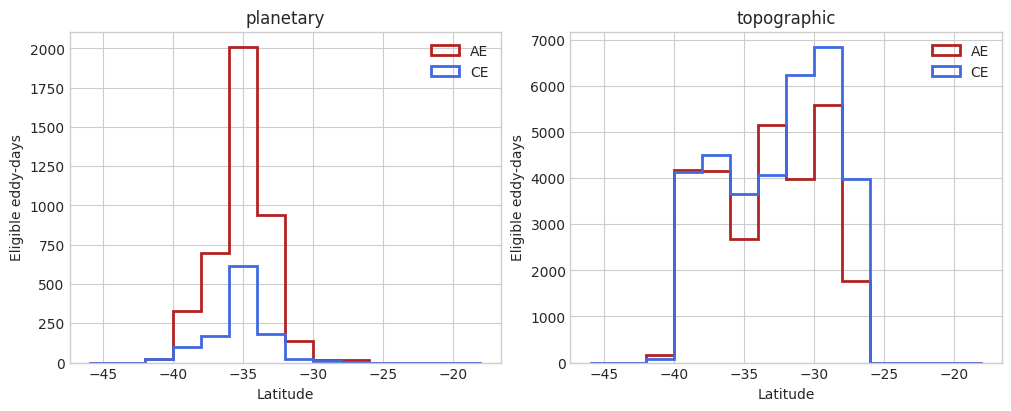

In [3]:
audit = data.groupby(['regime','Cyc'], observed=True).agg(
    days=('Day','size'), eddies=('track_id','nunique'), eligible_days=('eligible','sum'),
    median_lat=('lat','median'), median_h=('h','median'), median_tilt=('TiltDis','median')).reset_index()
table(audit, 'sample_audit')
support = eligible.groupby(ct.GROUPS, observed=True).agg(
    days=('Day','size'), eddies=('track_id','nunique'), episodes=('episode','nunique'),
    median_shear_ms=('shear_ms','median'), median_tilt_km=('TiltDis','median'),
    median_lat=('lat','median')).reset_index()
table(support, 'eligible_support')
fig, axes = plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
for ax, regime in zip(axes, ct.REGIMES):
    for cyc in ('AE','CE'):
        q = eligible.loc[eligible.regime.eq(regime)&eligible.Cyc.eq(cyc)]
        if len(q): ax.hist(q.lat.dropna(),bins=np.arange(-46,-17,2),histtype='step',lw=2,label=cyc,color=ct.COLORS[cyc])
    ax.set(title=regime,xlabel='Latitude',ylabel='Eligible eddy-days'); ax.legend()
show(fig,'latitude_coverage')

## 2. Preferred orientation and displacement
Primary estimates retain every qualifying day with equal weight. Whole-eddy bootstrap confidence intervals resample all records of each selected eddy together. Equal-eddy weighting is an explicit sensitivity (each eddy has equal total weight within the reported population). No median collapses disconnected episodes.

The angle histogram retains the distinction between left and right. A zero mean along-shear projection alone cannot distinguish cross-shear preference from mixed upshear/downshear populations. Confidence intervals are pointwise, not simultaneous tests across all bins; low-support estimates are shown in tables but omitted from inferential plots.

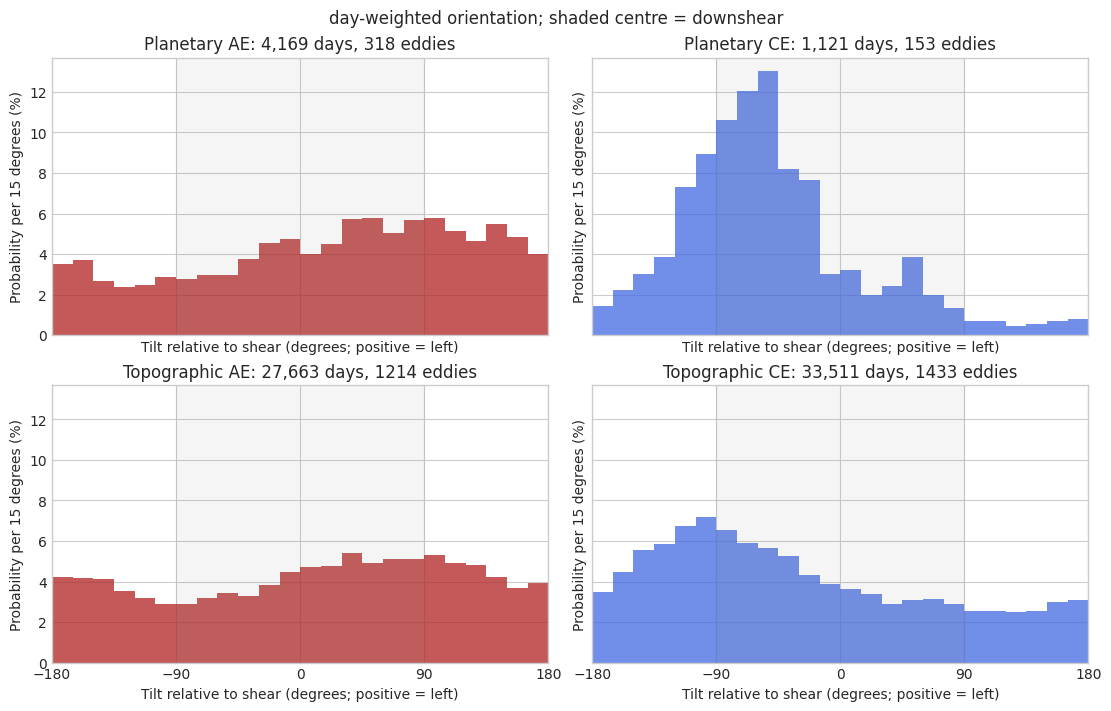

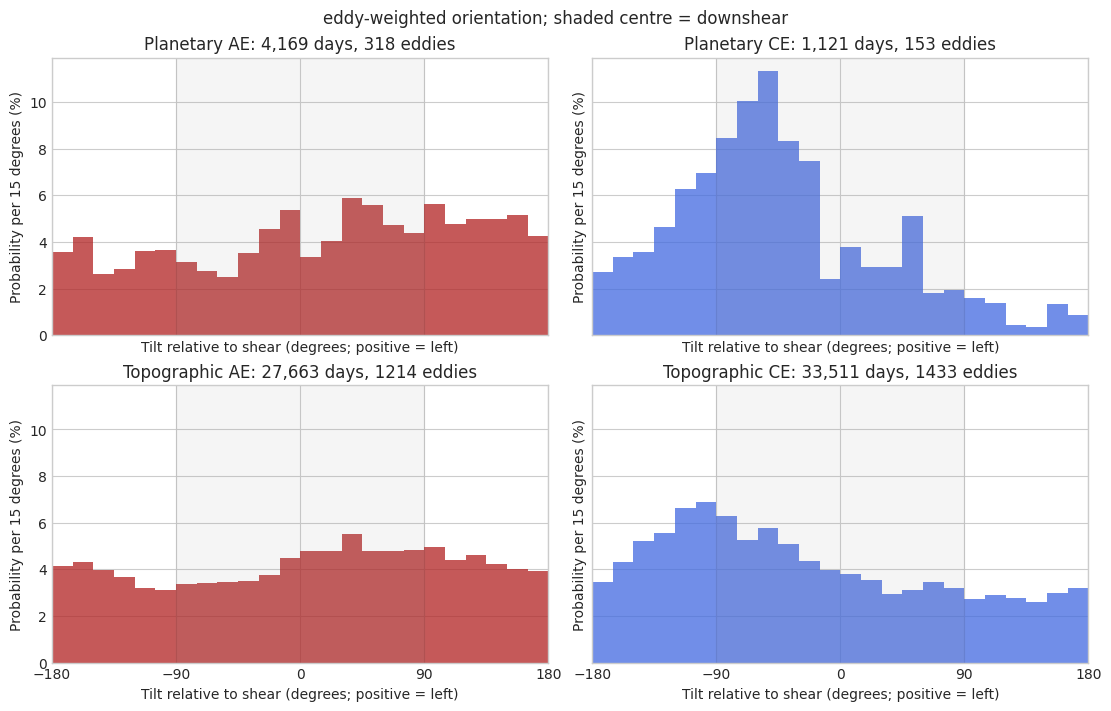

,regime,Cyc,metric,mean,ci_low,ci_high,eddies,observations,supported,weighting
0,planetary,AE,parallel_fraction,0.039225,-0.016929,0.095430,318,4169,True,day
1,planetary,AE,left_fraction,0.174576,0.127242,0.224946,318,4169,True,day
2,planetary,AE,parallel_km,-0.128544,-1.719411,1.107028,318,4169,True,day
3,planetary,AE,left_km,4.996836,3.478792,6.540682,318,4169,True,day
4,planetary,AE,upshear,0.475174,0.436613,0.512519,318,4169,True,day
5,planetary,CE,parallel_fraction,0.259318,0.171071,0.337017,153,1121,True,day
6,planetary,CE,left_fraction,-0.509301,-0.594485,-0.408553,153,1121,True,day
7,planetary,CE,parallel_km,4.639977,2.556890,6.473117,153,1121,True,day
8,planetary,CE,left_km,-10.120527,-12.375137,-7.700136,153,1121,True,day
9,planetary,CE,upshear,0.306869,0.251358,0.360790,153,1121,True,day


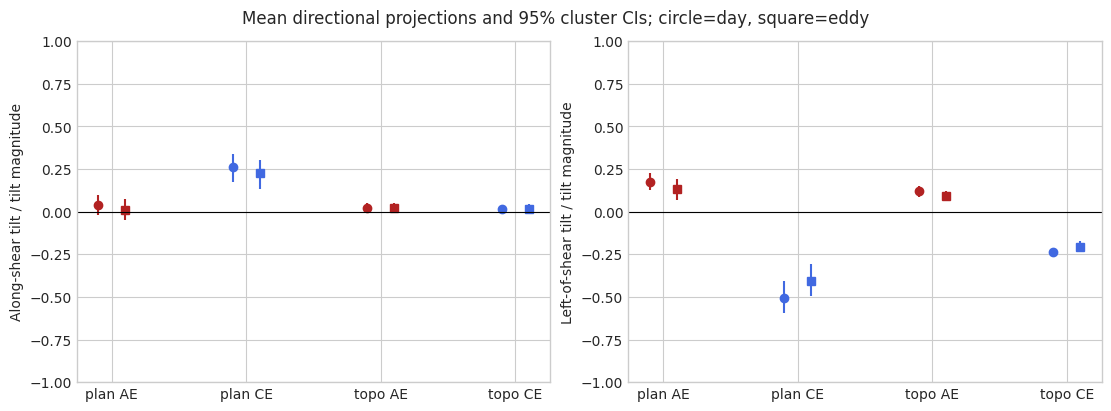

In [4]:
show(ct.plot_angles(data), 'angle_distributions_day')
show(ct.plot_angles(data, weighting='eddy'), 'angle_distributions_eddy')
STATIC = ['parallel_fraction','left_fraction','parallel_km','left_km','upshear']
static = pd.concat([summarize(eligible, STATIC, weighting=w) for w in ('day','eddy')], ignore_index=True)
table(static, 'static_scorecard')
fig, axes = plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
for ax, metric in zip(axes,['parallel_fraction','left_fraction']):
    labels=[]
    for x, (regime,cyc) in enumerate((r,c) for r in ct.REGIMES for c in ('AE','CE')):
        labels.append(f'{regime[:4]} {cyc}')
        for offset,w,marker in [(-.1,'day','o'),(.1,'eddy','s')]:
            q=static.loc[static.regime.eq(regime)&static.Cyc.eq(cyc)&static.metric.eq(metric)&static.weighting.eq(w)&static.supported]
            if len(q):
                r=q.iloc[0]
                ax.vlines(x+offset,r.ci_low,r.ci_high,color=ct.COLORS[cyc])
                ax.plot(x+offset,r['mean'],marker,color=ct.COLORS[cyc])
    ax.axhline(0,color='k',lw=.8); ax.set(xticks=range(4),xticklabels=labels,ylabel=ct.LABELS.get(metric,metric),ylim=(-1,1))
fig.suptitle('Mean directional projections and 95% cluster CIs; circle=day, square=eddy')
show(fig,'orientation_scorecard')

## 3. Conditional evolution in uninterrupted regime episodes
Each curve asks what happens next given the **initial** shear-relative angle. Change is projected onto the starting shear axes, preventing background rotation from masquerading as displacement change. A positive growth response means increasing TiltDis.

The movement of a vector relative to shear has two sources: the tilt rotates, or shear rotates. Both are shown separately. `fixed_shear_alignment_change_day` holds the starting shear direction fixed; positive means tilt itself becomes more downshear, negative more upshear. `alignment_change_day` uses the moving background direction. Their difference is informative, but do not add raw wrapped angles without circular arithmetic.

Conditioning on an initial noisy tilt can create apparent relaxation through regression to the mean. Endpoint selection (both tilts >= threshold) also conditions the sample. Multi-lag and threshold sensitivity are essential; a restoring-looking curve alone does not establish a physical restoring force.

,regime,Cyc,pairs,eddies,episodes,lag_days
0,planetary,AE,3595,293,497,1
1,planetary,CE,925,137,169,1
2,topographic,AE,25386,1187,2059,1
3,topographic,CE,30960,1412,2359,1
4,planetary,AE,2656,251,388,3
5,planetary,CE,613,104,121,3
6,topographic,AE,21443,1131,1732,3
7,topographic,CE,26419,1354,1997,3
8,planetary,AE,1950,200,276,5
9,planetary,CE,399,72,80,5


,regime,Cyc,angle_bin,metric,mean,ci_low,ci_high,eddies,observations,supported,weighting,lag_days
0,planetary,AE,-157.5,growth_km_day,-0.680376,-1.312933,-0.110035,96,323,True,day,1
1,planetary,AE,-157.5,dparallel_km_day,1.782672,1.118206,2.519058,96,323,True,day,1
2,planetary,AE,-157.5,dleft_km_day,-1.576357,-2.261608,-1.013458,96,323,True,day,1
3,planetary,AE,-157.5,tilt_rotation_deg_day,6.555041,4.465238,8.871220,96,323,True,day,1
4,planetary,AE,-157.5,shear_rotation_deg_day,0.736930,-0.949958,2.546588,96,323,True,day,1
...,...,...,...,...,...,...,...,...,...,...,...,...
763,topographic,CE,157.5,tilt_rotation_deg_day,-1.604110,-2.343255,-0.889114,387,1901,True,day,5
764,topographic,CE,157.5,shear_rotation_deg_day,-0.172176,-0.508865,0.166602,387,1901,True,day,5
765,topographic,CE,157.5,relative_rotation_deg_day,-1.318309,-2.134872,-0.492633,387,1901,True,day,5
766,topographic,CE,157.5,fixed_shear_alignment_change_day,0.053605,0.045512,0.060769,387,1901,True,day,5


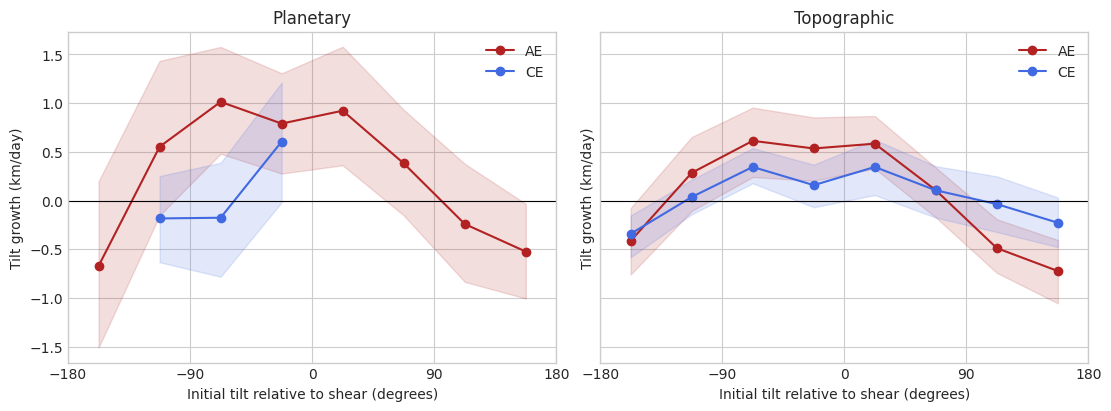

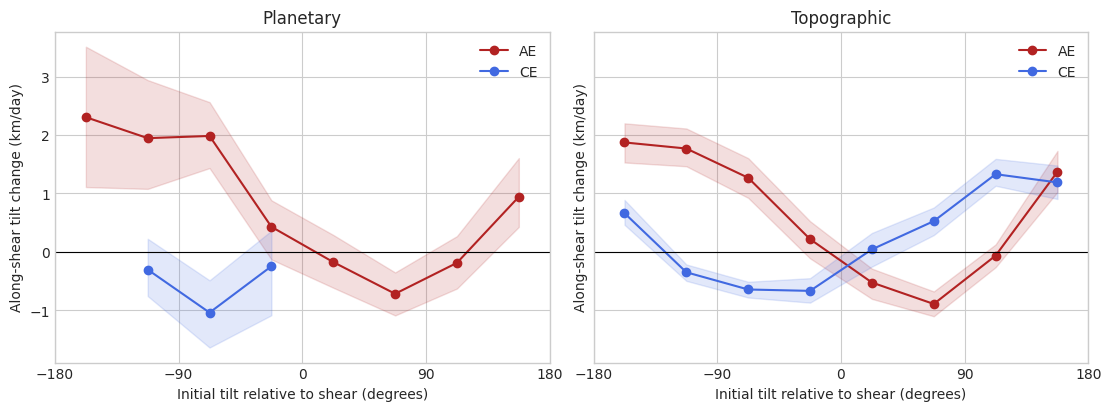

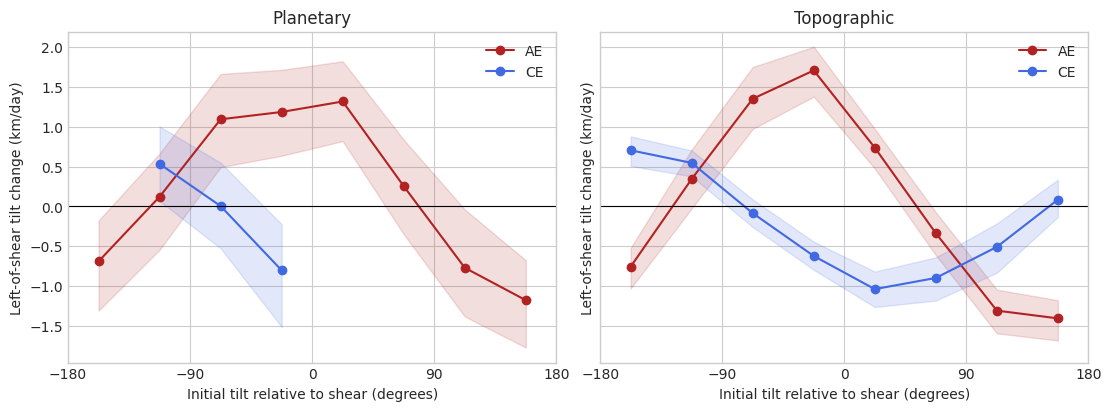

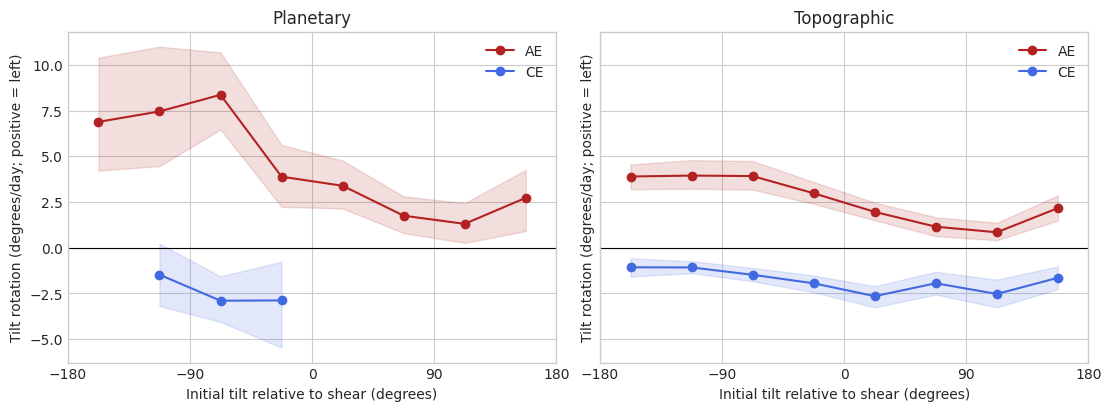

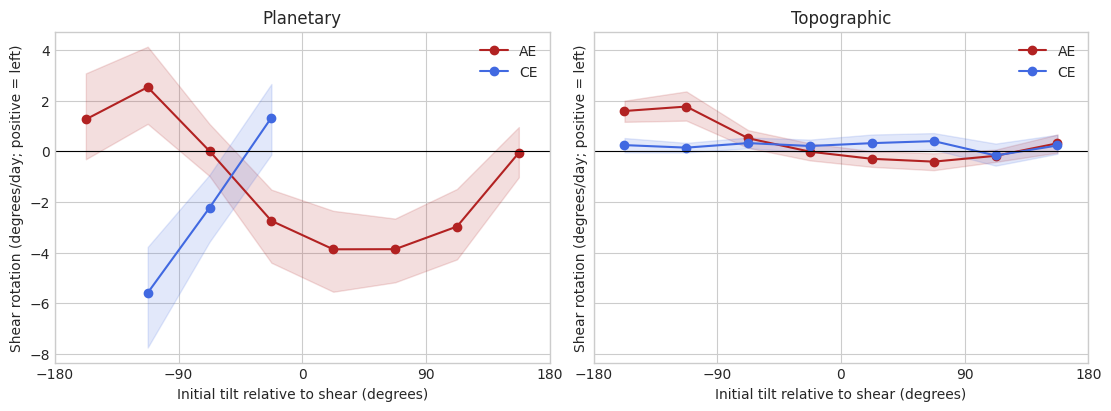

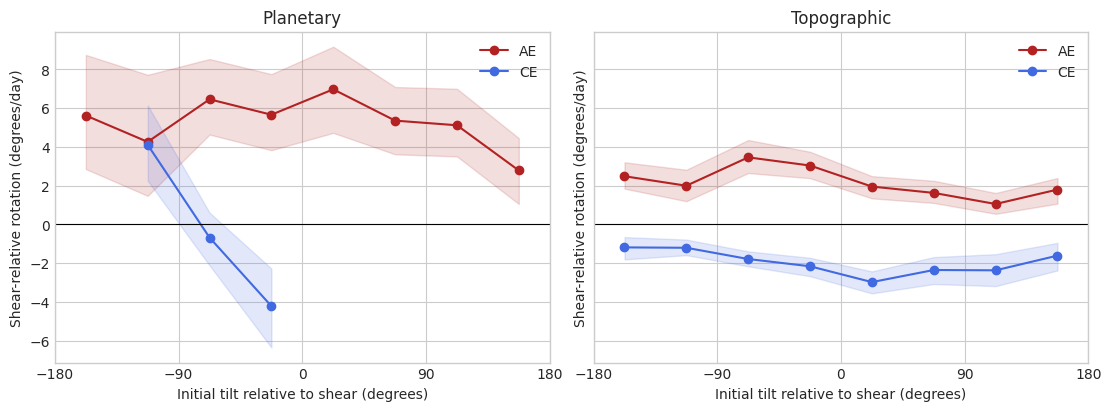

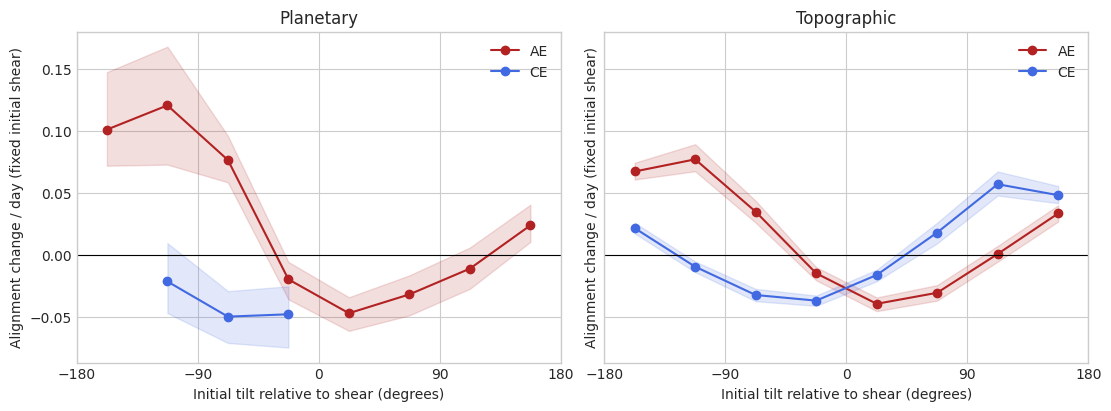

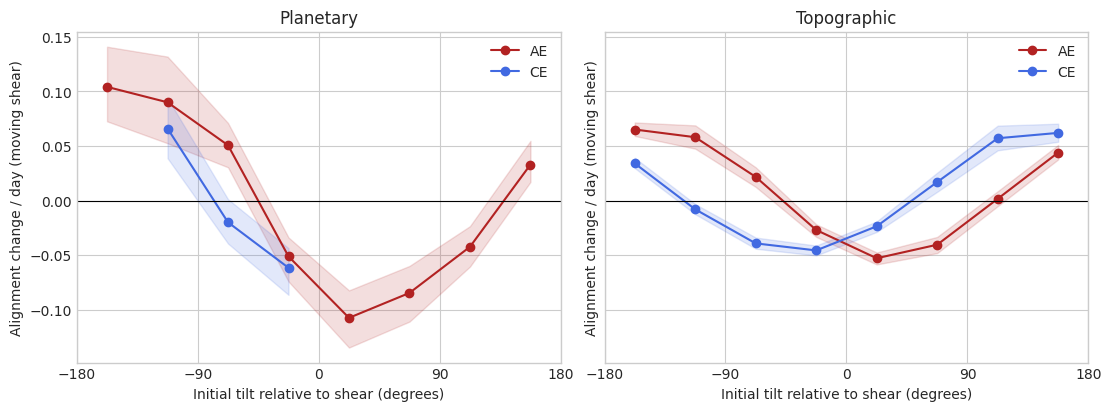

,regime,Cyc,angle_bin,eddies,observations,supported
256,planetary,AE,-157.5,69,206,True
264,planetary,AE,-112.5,62,181,True
272,planetary,AE,-67.5,78,253,True
280,planetary,AE,-22.5,92,373,True
288,planetary,AE,22.5,104,425,True
296,planetary,AE,67.5,103,472,True
304,planetary,AE,112.5,107,426,True
312,planetary,AE,157.5,86,320,True
320,planetary,CE,-157.5,17,39,False
328,planetary,CE,-112.5,38,127,True


In [5]:
EVOLUTION = ['growth_km_day','dparallel_km_day','dleft_km_day',
             'tilt_rotation_deg_day','shear_rotation_deg_day','relative_rotation_deg_day',
             'fixed_shear_alignment_change_day','alignment_change_day']
pairs_by_lag = {lag:ct.lagged_pairs(data, lag) for lag in LAGS}
pair_support = pd.concat([p.groupby(ct.GROUPS).agg(pairs=('Day','size'),eddies=('track_id','nunique'),
    episodes=('episode','nunique')).reset_index().assign(lag_days=lag) for lag,p in pairs_by_lag.items()],ignore_index=True)
table(pair_support,'lag_support')
conditional = pd.concat([summarize(p,EVOLUTION,groups=ct.GROUPS+['angle_bin']).assign(lag_days=lag)
                        for lag,p in pairs_by_lag.items()],ignore_index=True)
table(conditional,'conditional_evolution')
main = conditional.loc[conditional.lag_days.eq(PRIMARY_LAG)]
for metric in EVOLUTION:
    show(ct.plot_response(main,metric), f'{PRIMARY_LAG}d_{metric}')
# Pair support by initial orientation: unsupported bins must not be interpreted.
counts=main.loc[main.metric.eq('growth_km_day'), ['regime','Cyc','angle_bin','eddies','observations','supported']]
table(counts,'orientation_bin_support')

## 4. Persistence: starting versus future shear-relative orientation
Rows condition on the starting angle, columns show the future angle. A diagonal concentration indicates persistence over this lag. It does not prove wave phase locking. Only sufficiently supported starting-angle rows are displayed; zeros within a supported row mean no observed transitions, not missing data.

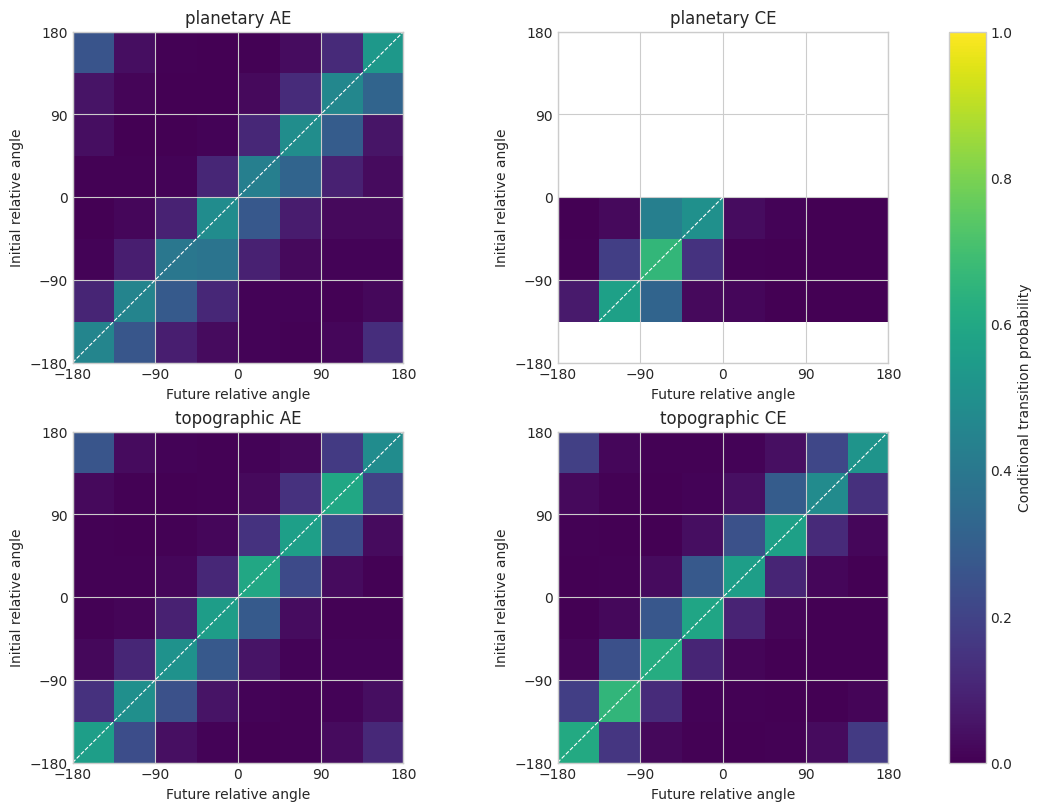

In [6]:
pairs = pairs_by_lag[PRIMARY_LAG]
fig,axes=plt.subplots(2,2,figsize=(11,8),constrained_layout=True)
centres=(ct.ANGLE_EDGES[:-1]+ct.ANGLE_EDGES[1:])/2
for i,regime in enumerate(ct.REGIMES):
    for j,cyc in enumerate(('AE','CE')):
        q=pairs.loc[pairs.regime.eq(regime)&pairs.Cyc.eq(cyc)].copy()
        q['future_bin']=pd.cut(q.future_angle_deg,ct.ANGLE_EDGES,right=False,labels=centres).astype(float)
        count=pd.crosstab(q.angle_bin,q.future_bin).reindex(index=centres,columns=centres,fill_value=0)
        support_q=q.groupby('angle_bin').agg(eddies=('track_id','nunique'),n=('Day','size')).reindex(centres,fill_value=0)
        prob=count.div(count.sum(axis=1).replace(0,np.nan),axis=0)
        prob.loc[(support_q.eddies<MIN_EDDIES)|(support_q.n<MIN_ROWS),:]=np.nan
        im=axes[i,j].imshow(prob,origin='lower',vmin=0,vmax=1,cmap='viridis',extent=(-180,180,-180,180))
        axes[i,j].plot([-180,180],[-180,180],'w--',lw=.8)
        axes[i,j].set(title=f'{regime} {cyc}',xlabel='Future relative angle',ylabel='Initial relative angle',
                      xticks=[-180,-90,0,90,180],yticks=[-180,-90,0,90,180])
fig.colorbar(im,ax=axes.ravel().tolist(),label='Conditional transition probability')
show(fig,'angle_transition_probability')

## 5. PV direction as a separate descriptive comparison
Project subsequent tilt-vector change on the **initial signed environmental PV gradient**, without imposing a polarity-dependent prediction. This proxy is not three-dimensional Ertel PV and it is not a force vector. Low net-gradient coherence makes its bearing unreliable, so the comparison requires coherence >= 0.2 and positive gradient magnitude. It cannot identify a causal PV contribution to the tilt budget.

,regime,Cyc,angle_bin,metric,mean,ci_low,ci_high,eddies,observations,supported,weighting
0,planetary,AE,-157.5,dpv_parallel_km_day,0.270614,-0.272059,0.864680,69,205,True,day
1,planetary,AE,-157.5,dpv_left_km_day,-1.609109,-2.772654,-0.507491,69,205,True,day
2,planetary,AE,-112.5,dpv_parallel_km_day,0.939540,0.174503,1.632542,60,176,True,day
3,planetary,AE,-112.5,dpv_left_km_day,-1.760012,-2.695943,-0.910634,60,176,True,day
4,planetary,AE,-67.5,dpv_parallel_km_day,1.507864,0.809114,2.208193,77,249,True,day
...,...,...,...,...,...,...,...,...,...,...,...
59,topographic,CE,67.5,dpv_left_km_day,0.153804,-0.066952,0.394983,443,2279,True,day
60,topographic,CE,112.5,dpv_parallel_km_day,-0.342972,-0.605219,-0.054692,432,1840,True,day
61,topographic,CE,112.5,dpv_left_km_day,-0.413546,-0.723492,-0.093118,432,1840,True,day
62,topographic,CE,157.5,dpv_parallel_km_day,0.001367,-0.259704,0.268446,438,2095,True,day


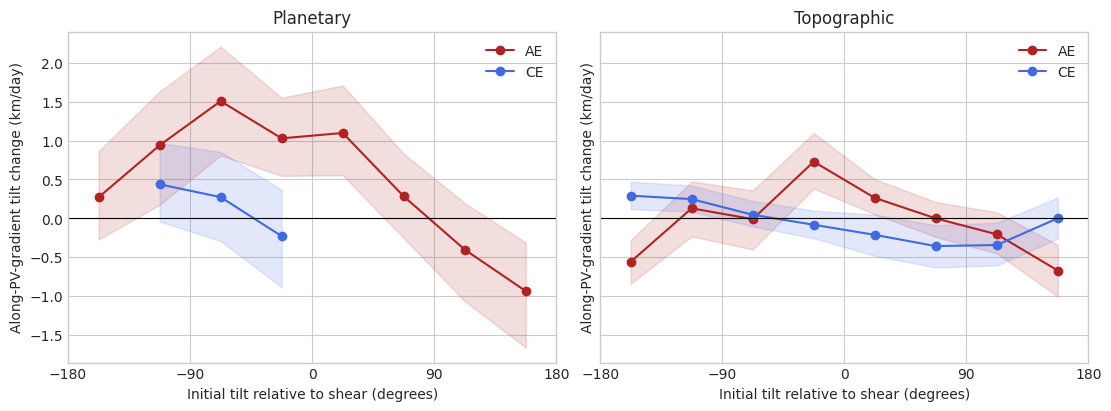

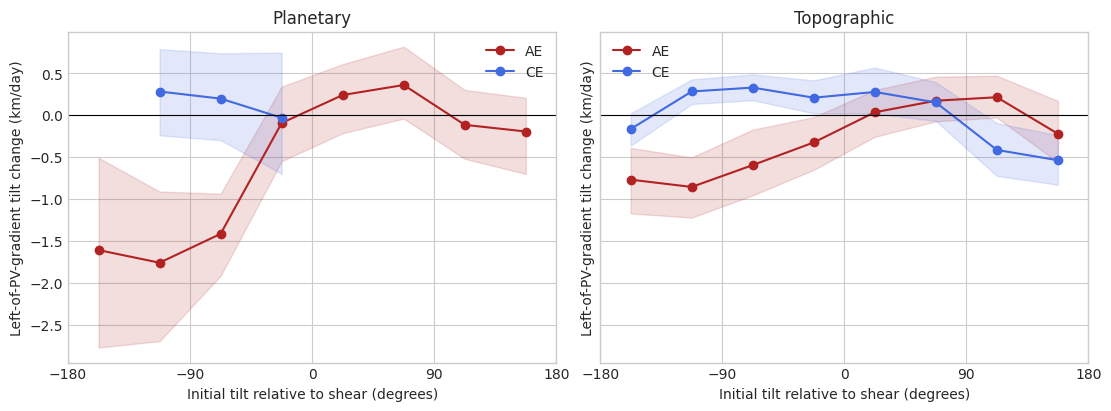

In [7]:
PV_MIN_COHERENCE = 0.2
if 'PV_grad_coherence' in pairs:
    pv_pairs=pairs.loc[pairs.PV_grad_coherence.ge(PV_MIN_COHERENCE)&pairs.PV_grad_mag.gt(0)].copy()
    pv_summary=summarize(pv_pairs,['dpv_parallel_km_day','dpv_left_km_day'],groups=ct.GROUPS+['angle_bin'])
    table(pv_summary,'pv_relative_evolution')
    for metric in ['dpv_parallel_km_day','dpv_left_km_day']:
        show(ct.plot_response(pv_summary,metric),metric)
else:
    print('PV directional comparison skipped: input cache has no coherence diagnostic.')

## 6. Latitude-stratified check
Compare the populations within fixed 2-degree latitude bands. This retains observations and avoids fitting a complex model before seeing sample support. It does not control season, eddy interactions, bathymetry or all spatial differences. Empty/unsupported bands are gaps, not zero responses. These curves complement the pooled scorecard; unequal latitude distributions can influence pooled regime/polarity contrasts.

,regime,Cyc,lat_band,metric,mean,ci_low,ci_high,eddies,observations,supported,weighting
0,planetary,AE,-41.0,parallel_fraction,0.185390,NaN,NaN,3,22,False,day
1,planetary,AE,-41.0,left_fraction,-0.706915,NaN,NaN,3,22,False,day
2,planetary,AE,-39.0,parallel_fraction,0.033683,-0.172251,0.241031,61,327,True,day
3,planetary,AE,-39.0,left_fraction,-0.081845,-0.223697,0.089234,61,327,True,day
4,planetary,AE,-37.0,parallel_fraction,-0.030794,-0.155537,0.087783,93,699,True,day
...,...,...,...,...,...,...,...,...,...,...,...
59,topographic,CE,-31.0,left_fraction,-0.271602,-0.337046,-0.208280,311,6244,True,day
60,topographic,CE,-29.0,parallel_fraction,-0.093725,-0.152852,-0.030105,329,6835,True,day
61,topographic,CE,-29.0,left_fraction,-0.300341,-0.353616,-0.238320,329,6835,True,day
62,topographic,CE,-27.0,parallel_fraction,-0.017661,-0.095746,0.072231,180,3980,True,day


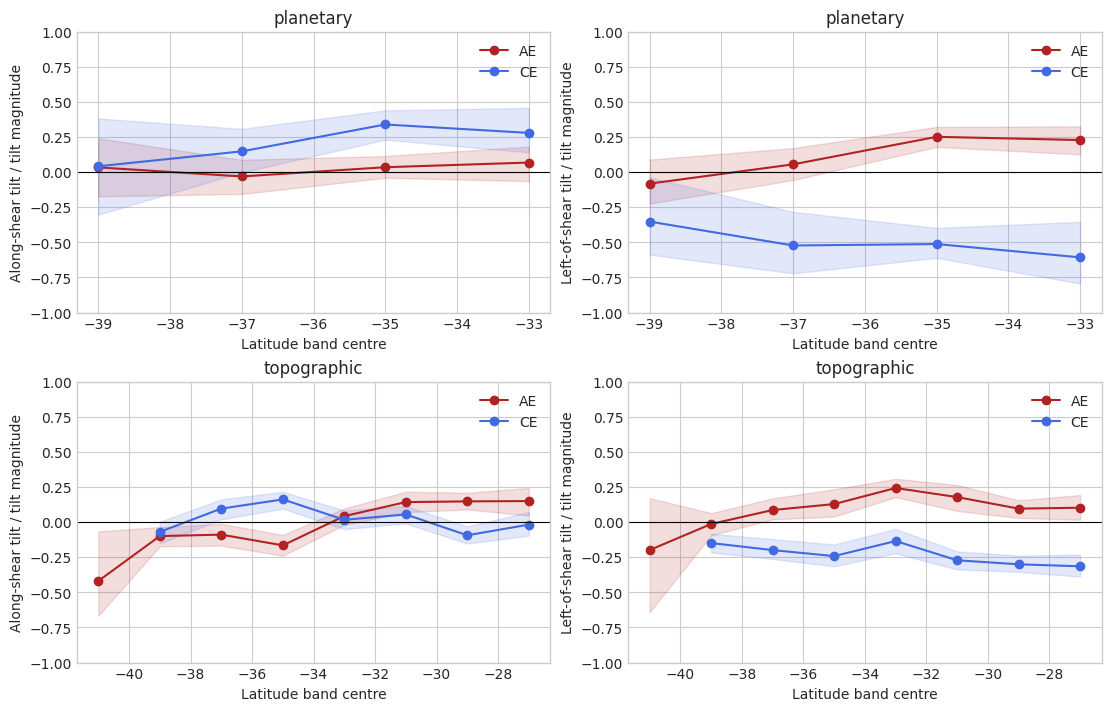

In [8]:
lat_data=eligible.copy()
lat_data['lat_band']=2*np.floor(lat_data.lat/2)+1
latitude=summarize(lat_data,['parallel_fraction','left_fraction'],groups=ct.GROUPS+['lat_band'])
table(latitude,'latitude_stratified_geometry')
fig,axes=plt.subplots(2,2,figsize=(11,7),constrained_layout=True)
for i,regime in enumerate(ct.REGIMES):
    for j,metric in enumerate(['parallel_fraction','left_fraction']):
        ax=axes[i,j]
        for cyc in ('AE','CE'):
            q=latitude.loc[latitude.regime.eq(regime)&latitude.Cyc.eq(cyc)&latitude.metric.eq(metric)].sort_values('lat_band')
            if len(q):
                ax.plot(q.lat_band,q['mean'].where(q.supported),'o-',label=cyc,color=ct.COLORS[cyc])
                ax.fill_between(q.lat_band.to_numpy(),q.ci_low.to_numpy(),q.ci_high.to_numpy(),alpha=.15,color=ct.COLORS[cyc])
        ax.axhline(0,color='k',lw=.8);ax.set(title=regime,ylabel=ct.LABELS.get(metric,metric),xlabel='Latitude band centre',ylim=(-1,1))
        if ax.get_legend_handles_labels()[0]: ax.legend()
show(fig,'latitude_stratified_geometry')

## 7. Prespecified sensitivity checks
Vary one setting at a time: full-archive versus seasonal background; surface-versus-deep contrast; tilt and weak-shear cutoffs; centred versus trailing regime smoothing; factor-of-three dominance. The surface comparison has the same whole-column mismatch limitation. Equal-eddy conditional evolution is also retained.

All lag endpoints and episodes are rebuilt for each setting. Differences can reflect changes in sample composition as well as measurement definition; tables report support. This is a robustness analysis, not a search for the smallest p-value. Stratification/eddy-strength interactions can be added after establishing the primary regime/polarity patterns.

,regime,Cyc,metric,mean,ci_low,ci_high,eddies,observations,supported,weighting,variant
0,planetary,AE,parallel_fraction,0.039225,-0.016929,0.095430,318,4169,True,day,primary
1,planetary,AE,left_fraction,0.174576,0.127242,0.224946,318,4169,True,day,primary
2,planetary,AE,parallel_km,-0.128544,-1.719411,1.107028,318,4169,True,day,primary
3,planetary,AE,left_km,4.996836,3.478792,6.540682,318,4169,True,day,primary
4,planetary,AE,upshear,0.475174,0.436613,0.512519,318,4169,True,day,primary
...,...,...,...,...,...,...,...,...,...,...,...
155,topographic,CE,parallel_fraction,0.009871,-0.018347,0.036861,1316,29202,True,day,dominance_3
156,topographic,CE,left_fraction,-0.231739,-0.258863,-0.203690,1316,29202,True,day,dominance_3
157,topographic,CE,parallel_km,0.296777,-0.615242,1.199278,1316,29202,True,day,dominance_3
158,topographic,CE,left_km,-6.162145,-7.149479,-5.328565,1316,29202,True,day,dominance_3


,regime,Cyc,angle_bin,metric,mean,ci_low,ci_high,eddies,observations,supported,weighting,variant
0,planetary,AE,-157.5,growth_km_day,-0.670870,-1.507579,0.197600,69,206,True,day,primary
1,planetary,AE,-157.5,fixed_shear_alignment_change_day,0.101039,0.067078,0.141492,69,206,True,day,primary
2,planetary,AE,-112.5,growth_km_day,0.552102,-0.134867,1.363028,62,181,True,day,primary
3,planetary,AE,-112.5,fixed_shear_alignment_change_day,0.120577,0.075092,0.168421,62,181,True,day,primary
4,planetary,AE,-67.5,growth_km_day,1.012722,0.474017,1.605178,78,253,True,day,primary
...,...,...,...,...,...,...,...,...,...,...,...,...
505,topographic,CE,67.5,fixed_shear_alignment_change_day,0.013603,0.005647,0.021983,396,2076,True,day,dominance_3
506,topographic,CE,112.5,growth_km_day,-0.047851,-0.352279,0.249719,382,1701,True,day,dominance_3
507,topographic,CE,112.5,fixed_shear_alignment_change_day,0.053210,0.043051,0.063581,382,1701,True,day,dominance_3
508,topographic,CE,157.5,growth_km_day,-0.114257,-0.420352,0.176790,412,1935,True,day,dominance_3


,regime,Cyc,angle_bin,metric,mean,ci_low,ci_high,eddies,observations,supported,weighting
0,planetary,AE,-157.5,growth_km_day,-0.233583,-0.946470,0.489003,69,206,True,eddy
1,planetary,AE,-157.5,dparallel_km_day,2.344370,1.466128,3.191339,69,206,True,eddy
2,planetary,AE,-157.5,dleft_km_day,-0.584818,-1.296175,0.208466,69,206,True,eddy
3,planetary,AE,-157.5,tilt_rotation_deg_day,7.790822,4.459529,11.123176,69,206,True,eddy
4,planetary,AE,-157.5,shear_rotation_deg_day,0.940449,-1.458408,3.402302,69,206,True,eddy
...,...,...,...,...,...,...,...,...,...,...,...
251,topographic,CE,157.5,tilt_rotation_deg_day,-3.148227,-4.170332,-2.106097,453,2225,True,eddy
252,topographic,CE,157.5,shear_rotation_deg_day,1.101710,0.429354,1.890632,453,2225,True,eddy
253,topographic,CE,157.5,relative_rotation_deg_day,-3.193759,-4.507867,-1.790877,453,2225,True,eddy
254,topographic,CE,157.5,fixed_shear_alignment_change_day,0.077077,0.066444,0.088527,453,2225,True,eddy


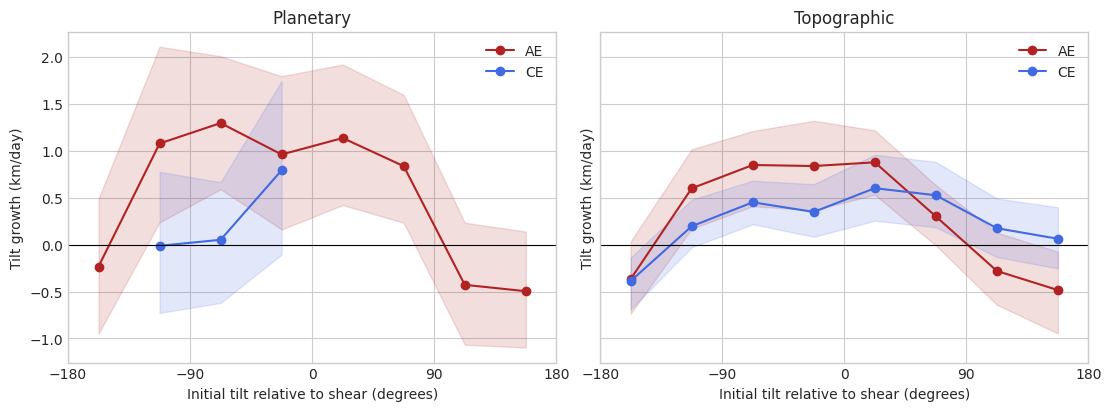

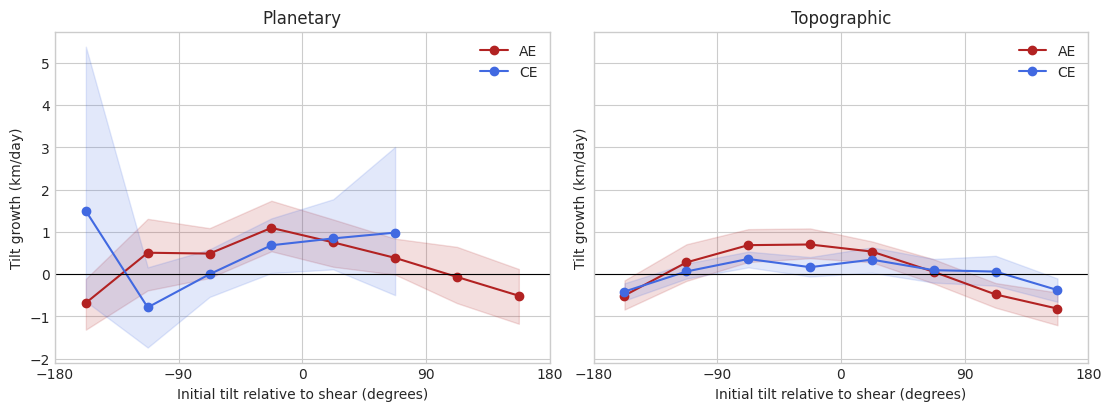

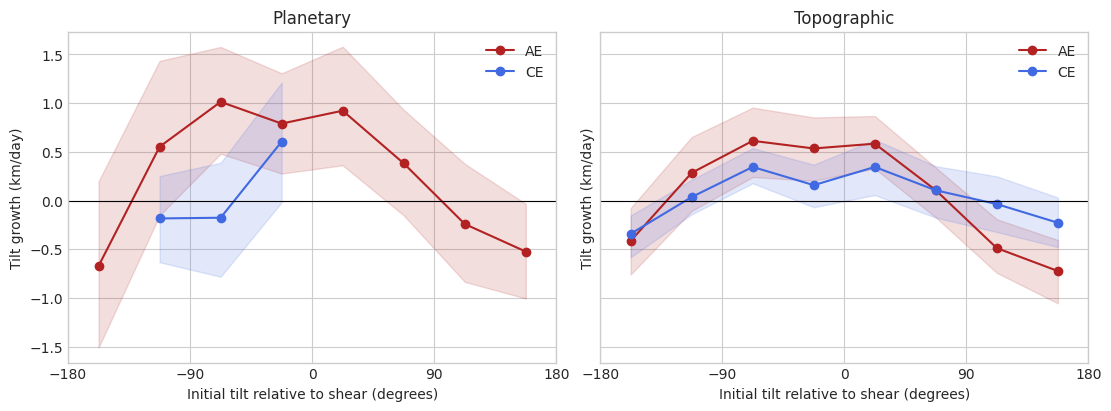

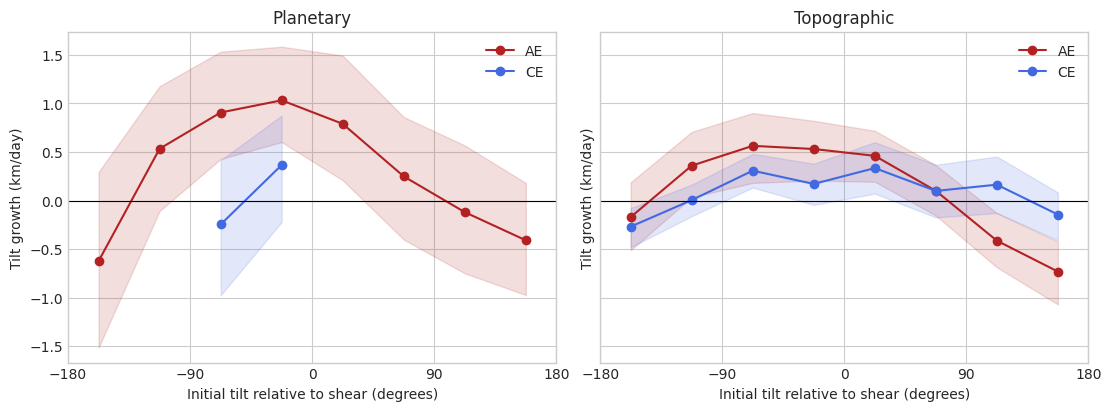

Saved outputs: /srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/shear_tilt_climatology/results/20260915T071453724762Z


In [9]:
sensitivity_static=[]; sensitivity_evolution=[]
if RUN_SENSITIVITIES:
    variants={'primary':{},'full_background':{'family':'full'},'surface_deep':{'definition':'surface_deep'},
              'tilt_2km':{'min_tilt':2.},'tilt_10km':{'min_tilt':10.},
              'shear_0.01':{'min_shear':.01},'centered_regime':{'smoothing':'centered'},
              'dominance_3':{'factor':3.}}
    for name,kw in variants.items():
        v=prepare(raw,**kw)
        s=summarize(v.loc[v.eligible],STATIC).assign(variant=name)
        sensitivity_static.append(s)
        lp=ct.lagged_pairs(v,PRIMARY_LAG)
        s=summarize(lp,['growth_km_day','fixed_shear_alignment_change_day'],groups=ct.GROUPS+['angle_bin']).assign(variant=name)
        sensitivity_evolution.append(s)
    table(pd.concat(sensitivity_static,ignore_index=True),'sensitivity_static')
    table(pd.concat(sensitivity_evolution,ignore_index=True),'sensitivity_evolution')
equal_evolution=summarize(pairs,EVOLUTION,groups=ct.GROUPS+['angle_bin'],weighting='eddy')
table(equal_evolution,'eddy_equal_evolution')
show(ct.plot_response(equal_evolution,'growth_km_day'),'eddy_equal_growth')
# Display all three horizons for growth, using identical bin boundaries.
for lag in LAGS:
    show(ct.plot_response(conditional.loc[conditional.lag_days.eq(lag)],'growth_km_day'),f'growth_lag_{lag}d')
print('Saved outputs:',OUTPUT if SAVE_OUTPUTS else 'disabled')

## Reading the result
1. Establish adequate support in all four populations and their latitude overlap.
2. Interpret along-shear and left/right projections together with the complete angle histograms.
3. Ask whether tilt grows, relaxes or rotates conditionally on its initial orientation; distinguish fixed-basis tilt reorientation from shear rotation.
4. Require agreement across lags, weights and reasonable thresholds before describing a robust climatological tendency. Excluding weak/small vectors and conditioning on initial angle can bias apparent persistence/relaxation.
5. Persistent orientation is evidence of organised geometry. A restoring-looking tendency is a hypothesis for dynamical maintenance, not proof of an unstable baroclinic mode. A next-stage mechanism test requires independent velocity/PV or energy diagnostics and matched depth support.

Whole-eddy clustering accommodates repeated observations within an eddy. Nearby eddies can remain mutually dependent; regional/year block robustness and interaction-aware subsets would be further checks for publication-level inference. The sample is all qualifying detected eddy-days, not an unbiased census of ocean volume or independent eddies.